In [1]:
!pip install pillow kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


# **Downloading Dataset**

In [2]:
import kagglehub

path = kagglehub.dataset_download("mohamedmaher5/vehicle-classification")
print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 827M/827M [00:11<00:00, 74.5MB/s]

Extracting files...


Path to dataset files: /Users/md.ajmainadil/.cache/kagglehub/datasets/mohamedmaher5/vehicle-classification/versions/1


# **Explore what's inside**

In [3]:
import os

for item in os.listdir(path):
    print(item)

Vehicles


# **Check the actual image folders**

In [4]:
# Try to find where the 7 category folders are

dataset_path = os.path.join(path, "Vehicles") 

# If Cell 3 already showed the 7 folders directly, use:
# dataset_path = path

# Let's see the categories and count images in each
for category in sorted(os.listdir(dataset_path)):
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):
        count = len(os.listdir(category_path))
        print(f"{category}: {count} images")

Auto Rickshaws: 800 images
Bikes: 800 images
Cars: 790 images
Motorcycles: 800 images
Planes: 800 images
Ships: 800 images
Trains: 800 images


# **Split data into Train / Validation / Test**

In [5]:
import tensorflow as tf

# Define image size and batch size
IMG_SIZE = (224, 224)  # MobileNetV2 expects 224x224 images
BATCH_SIZE = 32

# Create training set (70% of data)
train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,       # hold out 30% for val+test
    subset="training",
    seed=42,                     # makes the split reproducible
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Create the remaining 30% (we'll split this into val and test)
val_test_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Get class names before splitting further
class_names = train_data.class_names
print("Classes:", class_names)
print(f"Number of classes: {len(class_names)}")

Found 5588 files belonging to 7 classes.
Using 3912 files for training.
Found 5588 files belonging to 7 classes.
Using 1676 files for validation.
Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Number of classes: 7


# **Split the 30% into Validation and Test**

In [6]:
# Count how many batches are in val_test_data
val_test_size = tf.data.experimental.cardinality(val_test_data).numpy()
print(f"Total val+test batches: {val_test_size}")

# Split roughly in half: first half = validation, second half = test
val_size = val_test_size // 2

val_data = val_test_data.take(val_size)        # first half
test_data = val_test_data.skip(val_size)        # second half

print(f"Validation batches: {tf.data.experimental.cardinality(val_data).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_data).numpy()}")

Total val+test batches: 53
Validation batches: 26
Test batches: 27


# **Optimize data loading**

In [7]:
# This makes training faster by loading data in the background
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

print("Data pipeline ready!")


Data pipeline ready!


# **Build the Model**

In [8]:
# Load MobileNetV2 — pretrained on ImageNet (1.4 million images)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model — don't change what it already learned
base_model.trainable = False

# Build our full model
model = tf.keras.Sequential([
    # Preprocessing: scale pixel values from 0-255 to -1 to 1
    tf.keras.layers.Rescaling(1./127.5, offset=-1, input_shape=(224, 224, 3)),
    
    # The pretrained base (frozen)
    base_model,
    
    # Our custom layers on top
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Compiling the model**


In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# **Train the Model**

In [10]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


2026-03-06 01:17:03.323434: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
2026-03-06 01:17:03.414947: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
2026-03-06 01:17:03.815113: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
2026-03-06 01:17:04.490434: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
2026-03-06 01:17:04.683851: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8046 - loss: 0.5835 

2026-03-06 01:17:23.581959: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
2026-03-06 01:17:26.457244: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent


123/123 ━━━━━━━━━━━━━━━━━━━━ 26s 181ms/step - accuracy: 0.9208 - loss: 0.2453 - val_accuracy: 0.9844 - val_loss: 0.0530
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.9811 - loss: 0.0608 - val_accuracy: 0.9856 - val_loss: 0.0514
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 160ms/step - accuracy: 0.9885 - loss: 0.0381 - val_accuracy: 0.9892 - val_loss: 0.0406
Epoch 4/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 164ms/step - accuracy: 0.9911 - loss: 0.0267 - val_accuracy: 0.9868 - val_loss: 0.0396
Epoch 5/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.9939 - loss: 0.0174 - val_accuracy: 0.9904 - val_loss: 0.0427
Epoch 6/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.9946 - loss: 0.0197 - val_accuracy: 0.9904 - val_loss: 0.0359
Epoch 7/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.9962 - loss: 0.0112 - val_accuracy: 0.9880 - val_loss: 0.0493
Epoch 8/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.9957 - loss: 0.0161 - val

# **Plot Training Curves**

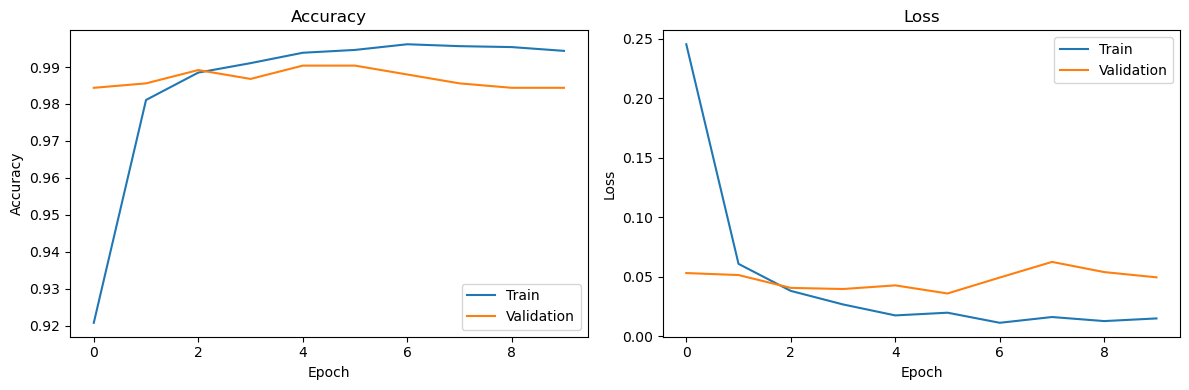

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

# Loss plot
ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Validation")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

 # **Evaluate on Test Set**

In [12]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

2026-03-06 01:25:22.505576: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
2026-03-06 01:25:22.808771: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent


 1/27 ━━━━━━━━━━━━━━━━━━━━ 24s 953ms/step - accuracy: 0.9375 - loss: 0.1062

2026-03-06 01:25:23.240755: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.9905 - loss: 0.0459 

Test Accuracy: 99.05%


 # **Confusion Matrix**

2026-03-06 01:25:46.655324: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


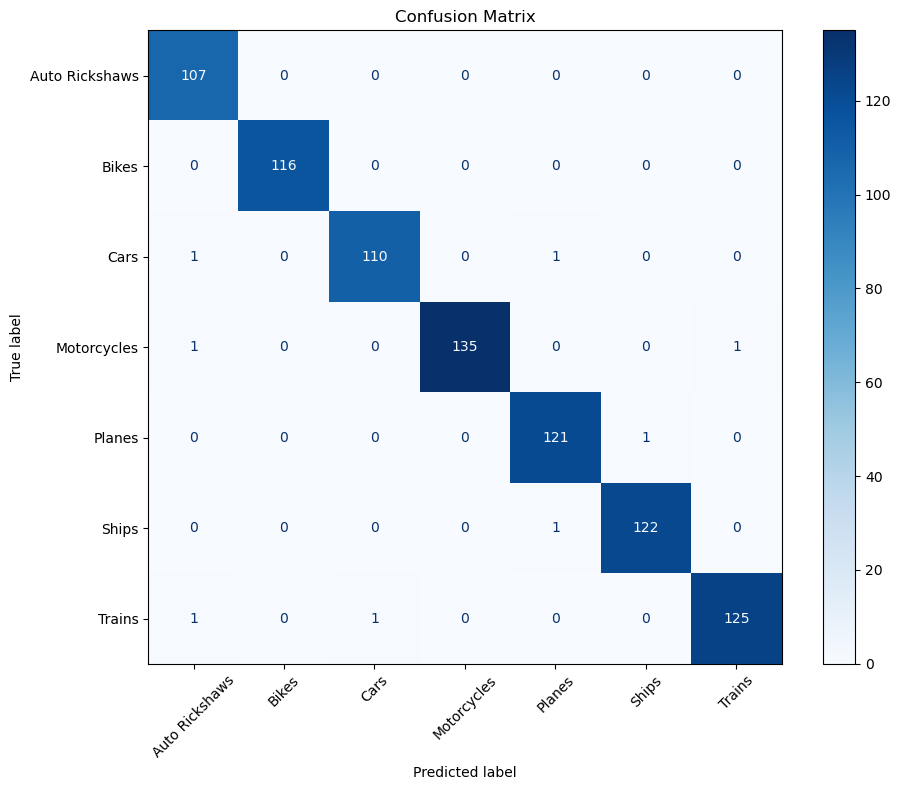

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions on test set
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
model.save("vehicle_classifier.keras")
print("Model saved!")

Model saved!
